In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

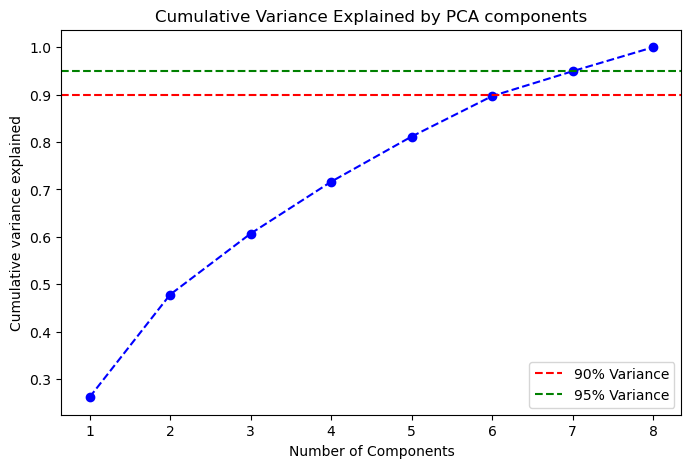

In [13]:
df= pd.read_csv ('diabetes.csv')
numerical_cols = ['Pregnancies','Glucose','BloodPressure',
                 'SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

# Handle missing values for numerical columns
numerical_data = df[numerical_cols]
imputer_num = SimpleImputer(strategy='mean')
numerical_data = imputer_num.fit_transform(numerical_data)
numerical_df = pd.DataFrame(numerical_data,columns=numerical_cols)

# Standardize data
scaler =  StandardScaler()
data_scaled = scaler.fit_transform(numerical_df)

# apply PCA
pca =  PCA()
x_pca = pca.fit_transform(data_scaled)

# Variance captured by each component
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1),cumulative_variance, marker='o',
        linestyle='--',color='b')
plt.title('Cumulative Variance Explained by PCA components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative variance explained')
plt.axhline(y=0.9,color='r',linestyle='--',label='90% Variance')
plt.axhline(y=0.95,color='g',linestyle='--',label='95% Variance')
plt.legend()
plt.show()

In [15]:
# Display PCA results
print('Explained Variance Ratio (for each PC):')
print(explained_variance)
print('\nCumulative Variance:')
print(cumulative_variance)

# Show composition (loadings) of each principal component 
loadings = pd.DataFrame(
    pca.components_,
    columns=numerical_cols,
    index=[f'pc{i+1}' for i in range(len(numerical_cols))]
)
print('\ncomposition of each principal component:')
print(loadings)

# select first three principal components
x_selected = x_pca[:,:3]
#prepare the target variable
y = df['Outcome']
# split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_selected,y,test_size=0.2,random_state=42)

# Train a Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f'Accuracy:{accuracy:.2f}')
print(conf_matrix)
print(report)

Explained Variance Ratio (for each PC):
[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]

Cumulative Variance:
[0.26179749 0.47819876 0.60690249 0.71634362 0.81163667 0.89696522
 0.94944224 1.        ]

composition of each principal component:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
pc1     0.128432  0.393083       0.360003       0.439824  0.435026  0.451941   
pc2     0.593786  0.174029       0.183892      -0.331965 -0.250781 -0.100960   
pc3     0.013087 -0.467923       0.535494       0.237674 -0.336709  0.361865   
pc4     0.080691 -0.404329       0.055986       0.037976 -0.349944  0.053646   
pc5     0.475606 -0.466328      -0.327953       0.487862  0.346935 -0.253204   
pc6     0.193598  0.094162      -0.634116       0.009589 -0.270651  0.685372   
pc7    -0.588790 -0.060153      -0.192118       0.282213 -0.132010 -0.035366   
pc8     0.117841  0.450355      -0.011296       0.566284 -0.548621 -0.3415